In [1]:
import os

# Replace with your actual Kaggle username
KAGGLE_USERNAME = "ifa666zi"  # e.g., "Ela123"
KAGGLE_KEY = "KGAT_96e0645b79f242128fb356ecec4c7c56"  # your API key

# Make the Kaggle config folder
os.makedirs("/root/.kaggle/", exist_ok=True)

# Write the kaggle.json file
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write('{"username":"%s","key":"%s"}' % (KAGGLE_USERNAME, KAGGLE_KEY))

# Set proper permissions
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [2]:
# Download Chest X-ray Pneumonia dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Check the downloaded zip
!ls

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:13<00:00, 246MB/s]
100% 2.29G/2.29G [00:13<00:00, 180MB/s]
chest-xray-pneumonia.zip  sample_data


In [3]:
# Unzip the dataset into 'data/' folder
!mkdir -p data
!unzip -q chest-xray-pneumonia.zip -d data/

# Check the structure
!ls data/chest_xray

chest_xray  __MACOSX  test  train  val


In [4]:
import os

for split in ["train","val","test"]:
    if os.path.exists(f"data/chest_xray/{split}/NORMAL"):
        os.rename(f"data/chest_xray/{split}/NORMAL", f"data/chest_xray/{split}/Normal")
    if os.path.exists(f"data/chest_xray/{split}/PNEUMONIA"):
        os.rename(f"data/chest_xray/{split}/PNEUMONIA", f"data/chest_xray/{split}/Pneumonia")

# Verify
!ls data/chest_xray/train

Normal	Pneumonia


In [5]:
# ================= Block 4: Dataset & DataLoaders (FAST VERSION) =================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

train_dir = "data/chest_xray/train"
val_dir   = "data/chest_xray/val"
test_dir  = "data/chest_xray/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transform)

batch_size = 32   # faster

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 5216
Val: 16
Test: 624


In [6]:
# ================= Block 5: Model Definition =================
import torch
from torchvision import models
import torch.nn as nn

# Use pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 1),
    nn.Sigmoid()  # for binary classification
)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# ================= Block 6: Loss & Optimizer =================
import torch.optim as optim

criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
# ================= Block 7: Training Function =================
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss = 0
        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")):
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # ---- Validation ----
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Saved Best Model")

        torch.cuda.empty_cache()

In [9]:
# ================= Block 8: Train =================
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5)

Epoch 1 [Val]: 100%|██████████| 1/1 [00:00<00:00,  1.56it/s]


Epoch [1/5] - Train Loss: 0.1515 | Val Loss: 0.1352
Saved Best Model


Epoch 2 [Val]: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


Epoch [2/5] - Train Loss: 0.0682 | Val Loss: 0.1875


Epoch 3 [Val]: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


Epoch [3/5] - Train Loss: 0.0477 | Val Loss: 0.0600
Saved Best Model


Epoch 4 [Val]: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


Epoch [4/5] - Train Loss: 0.0426 | Val Loss: 0.2853


Epoch 5 [Val]: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]

Epoch [5/5] - Train Loss: 0.0327 | Val Loss: 0.1205


Threshold: 0.5
Accuracy: 0.8638
Precision: 0.8224
Recall: 0.9974
F1 Score: 0.9015
ROC-AUC: 0.8192
Confusion Matrix:
[[150  84]
 [  1 389]]


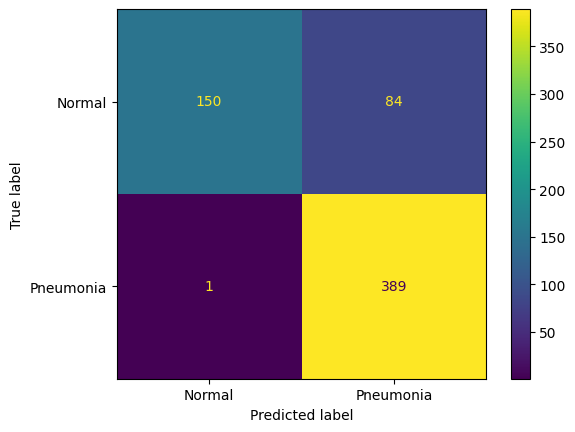

In [10]:
# ================= Block 9: Evaluation =================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

threshold = 0.5
all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        outputs = model(images)
        preds = (outputs > threshold).int()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Compute metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Threshold: {threshold}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
ConfusionMatrixDisplay(cm, display_labels=["Normal","Pneumonia"]).plot()

In [11]:
# Save metrics to CSV
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC-AUC": roc_auc
}
import pandas as pd
df = pd.DataFrame([results])
df.to_csv("test_metrics.csv", index=False)
print("Metrics saved to test_metrics.csv")

Metrics saved to test_metrics.csv


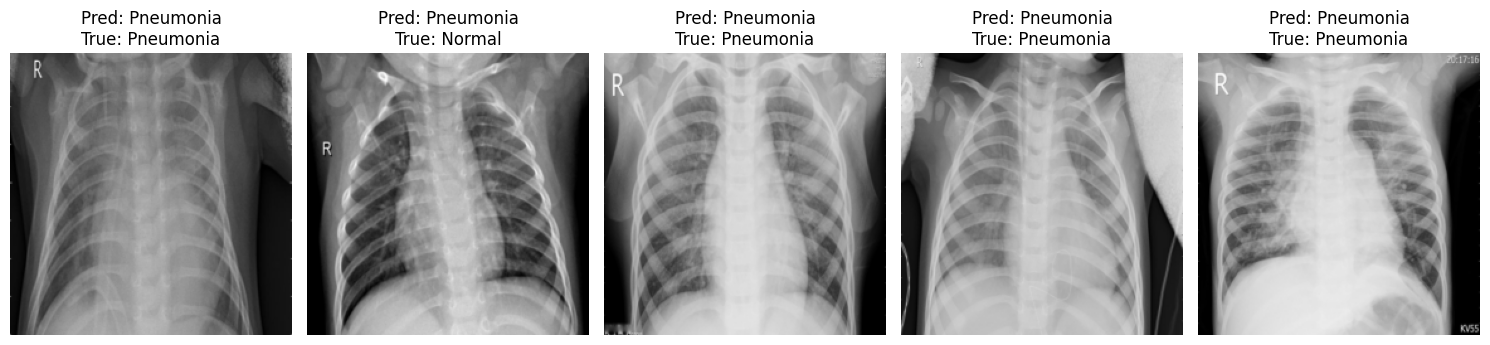

In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Pick 5 random images from test set
import random
indices = random.sample(range(len(test_dataset)), 5)

model.eval()
plt.figure(figsize=(15,5))

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = int((output > 0.5).cpu().numpy()[0][0])

    # Denormalize
    img_show = img.permute(1,2,0).numpy() * 0.5 + 0.5

    plt.subplot(1,5,i+1)
    plt.imshow(img_show, cmap='gray')
    plt.title(f"Pred: {'Pneumonia' if pred else 'Normal'}\nTrue: {'Pneumonia' if label else 'Normal'}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png")  # save for GitHub
plt.show()